# **Proyecto NLP**

* Aplicar un flujo básico de procesamiento de lenguaje natural (NLP) para resolver un problema de clasificación.
* Objetivo: Queremos implementar un sistema que sea capaz de detectar automáticamente si una página web contiene spam o no basándonos en su URL.

* El proyecto incluye:  
        - Análisis exploratorio de datos (EDA)  
        - Extracción de características de URLs  
        - Vectorización de texto  
        - Entrenamiento de modelos de clasificación

**APUNTES:** 
* Info del modelo: https://bbycroft.net/llm

## **Imports**

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

## **EDA**

* ¿Qué palabras aportan al objetivo de analizar si una pagina es spam o no? --> Investigar y analizar data

### **Lectura e información de los datos**

In [123]:
df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv")
df.head()


,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [124]:
df.shape

(2999, 2)

In [ ]:
df.info()

> **Observaciones:**  
> * El df contiene 2999 filas y 2 columnas  
> * Columnas y filas :  
>           - url = texto (dirección url)  
>           - is_spam = etiqueta (¿el url pertenece a un spam? ¿si o no?)  


### **Limpieza de datos**

* **Valores nulos**

In [126]:
df.isnull().sum()

url        0
is_spam    0
dtype: int64

* **Valores duplicados**

In [159]:
df.duplicated().sum()

np.int64(630)

In [161]:
df[df["url"].duplicated()].head()

,url,is_spam,url_length,digits_count,special_chars,slash_count,spam_word_count,url_limpio
60,https://briefingday.us8.list-manage.com/unsubs...,True,51,1,8,3,0,https briefingday us list manage com unsubscribe
61,https://www.hvper.com/,True,22,0,6,3,0,https www hvper com
62,https://briefingday.com/m/v4n3i4f3,True,34,4,6,4,0,https briefingday com m v n i f
64,https://briefingday.com/fan,True,27,0,5,3,0,https briefingday com fan
113,https://briefingday.com/fan,True,27,0,5,3,0,https briefingday com fan


In [162]:
df = df.drop_duplicates(subset="url")

### **Balance de clases**

* Permite detectar desbalanceo de clases que suele ser algo común en problemas de spam.

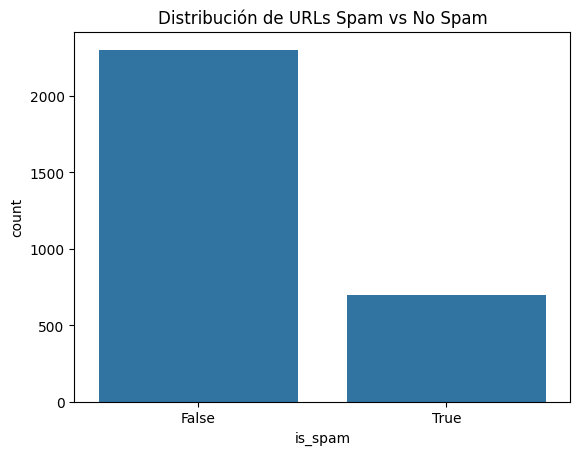

In [127]:
sns.countplot(x="is_spam", data=df)
plt.title("Distribución de URLs Spam vs No Spam")
plt.show()

> **Observaciones:**  Destaca un gran numero de url no spam en el dataset además de una diferencia notbale entre las dos clases. (False = no spam, True = spam)

### **Future engineering (Análisis de las variables)**

* **Importante:** Extraer patrones estructurales de la URL.

* Las URLs de spam suelen ser más largas para ocultar palabras sospechosas.

#### 1. **Conteo de data**

In [128]:
df["url_length"] = df["url"].apply(len)

<Axes: xlabel='is_spam', ylabel='url_length'>

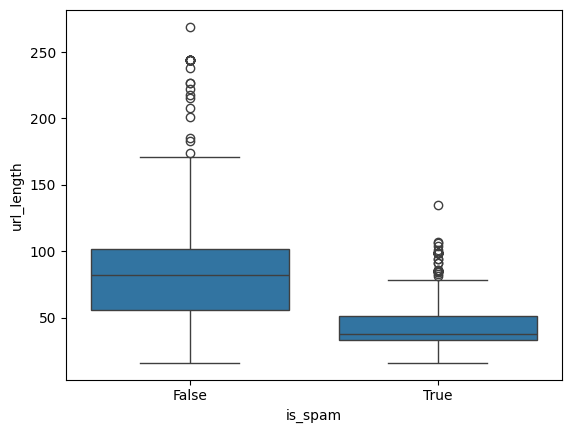

In [129]:
sns.boxplot(x="is_spam", y="url_length", data=df)

> **Observaciones:** Las url más largas se determinan como no spam en cambio las más cortas sí serían spam: También se detectan más concentración de outliers en las url spam.

* **Número de dígitos:** Las url Spam usa muchos números.

In [165]:
df["digits_count"] = df["url"].apply(lambda x: sum(c.isdigit() for c in x))
df['digits_count'].count()

np.int64(2369)

* **Número de caracteres especiales:** Las URLs maliciosas utilizan más símbolos y separadores para disfrazar el enlace.

In [166]:
df["special_chars"] = df["url"].apply(lambda x: len(re.findall(r"[^\w\s]", x)))
df["special_chars"].count()

np.int64(2369)

* **Número de subdirectorios:** Las URLs de spam suelen tener muchos subdirectorios falsos.

In [167]:
df["slash_count"] = df["url"].apply(lambda x: x.count("/"))
df["slash_count"].count()

np.int64(2369)

#### 2. **Detección de palabras sosprechosas**

Palabras sospechosas:

* free
* login
* verify
* account
* update
* secure
* bank
* bonus
* win
* credit
* offer
* click* 

In [133]:
spam_words = ["free","login","verify","account","update","bonus","bank","secure","win"]

def contains_spam_words(url):
    url = url.lower()
    return sum(word in url for word in spam_words)

df["spam_word_count"] = df["url"].apply(contains_spam_words)

## **Procesamiento de texto**

* **Conversión del texto de la url**

In [134]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-zA-Z]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df["url_limpio"] = df["url"].apply(limpiar_texto)

* **Palabras comunes**

In [135]:
vectorizer = CountVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(df['url_limpio'])
words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

freq = pd.DataFrame({"word": words,"count": counts}).sort_values("count", ascending=False)

freq.head(20)

,word,count
8257,https,2945
3482,com,2615
19443,www,1856
8589,https www,1844
16865,the,399
8236,html,354
18230,us,318
11608,news,307
17388,to,238
11179,morningbrew,226


* **Palabras comunes en spam** : Permite identificar tokens asociados al spam. DUDA--> Como funciona?

In [136]:
spam_urls = df[df["is_spam"]==1]["url"]

vectorizer = CountVectorizer(stop_words="english")
X_spam = vectorizer.fit_transform(spam_urls)

words = vectorizer.get_feature_names_out()
counts = X_spam.sum(axis=0).A1

spam_freq = pd.DataFrame({
    "word": words,
    "count": counts
}).sort_values("count", ascending=False)

spam_freq.head(20)

,word,count
236,https,673
124,com,620
474,www,305
309,morningbrew,133
321,numlock,86
293,manage,72
145,daily,64
421,theskimm,59
288,list,56
407,substack,56


### **Declarar variables**

In [137]:
X_text = df["url_limpio"]
y = df["is_spam"]

### **Split data train - test**

In [138]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **ML**

### **CountVectorizer**

El modelo utilizado 'countVectorizer' trabaja con Bag of Words (BoW), que solo cuenta si una palabra aparece o no, no tiene en cuenta el orden y no detecta relaciones entre palabras.


Si no se interpreta el siginificado del texto o si cambia el orden de palabras también puede cambiar el significado del texto pero el modelo no toma la relacion entre palabras. De esta manera se puede perder informacion por el camino del análisis o filtrado de datos.

El parámetro 'ngram_range=(1,2)' combina la deteccion de palabras individuales(unigramas) + pares de palabras(bigramas).



In [139]:
vectorizer = CountVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(X_text)
print(vectorizer.get_feature_names_out())
print(X.toarray())

['aa' 'aa acebbd' 'aa da' ... 'zwn oocqkxg' 'zyguxzjc' 'zyguxzjc cs']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [140]:
vect_df = pd.DataFrame(X.todense(), columns=vectorizer.get_feature_names_out())
vect_df["is_spam"] = y # vect_df["Resultado Esperado"] = df["is_spam"]

vect_df.head()

,aa,aa acebbd,aa da,aa df,aa eabf,aa ecf,aa fb,aa fd,aa html,aa mc,...,zulalimtm,zulalimtm tzubyqym,zwift,zwift com,zwift training,zwn,zwn oocqkxg,zyguxzjc,zyguxzjc cs,is_spam
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,True
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,True
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,True
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,False
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,True


### **Transformers**

Modelo entrenado que tiene en cuenta el orden y la relacion de las palabras.

In [141]:
vectorizer = TfidfVectorizer(ngram_range=(1,2),stop_words="english")
X = vectorizer.fit_transform(X_text)

### **Naive Bayes**

* **Crear y entrenar del modelo**

In [142]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


* **Predicciones:**

In [143]:
y_pred = model.predict(X_test)

* **Evaluación del modelo (Accuracy)**:

In [144]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8416666666666667


* **Test data vs Data predicha**

In [145]:
resultados = pd.DataFrame({"Real": y_test,"Prediccion": y_pred})
resultados.head()

,Real,Prediccion
1376,True,True
932,False,False
144,False,False
1752,True,True
51,False,False


### **Modelo SVM**

* **Crear y entrenar el modelo**

In [146]:
svm_model = SVC()

In [147]:
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


* **Predicciones:**

In [148]:
y_pred_svm = svm_model.predict(X_test)

* **Evaluación del modelo (Accuracy)**:

In [149]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy SVM:", accuracy_svm)

Accuracy SVM: 0.93


* **Métricas:**

In [150]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

       False       0.93      0.99      0.96       455
        True       0.95      0.75      0.84       145

    accuracy                           0.93       600
   macro avg       0.94      0.87      0.90       600
weighted avg       0.93      0.93      0.93       600



### **Optimización del modelo (GridSearch)**

In [151]:
param_grid = {'C':[0.1, 1, 10],'kernel':['linear', 'rbf'],'gamma':['scale', 'auto']}
grid = GridSearchCV(SVC(),param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [152]:

print("Mejores parámetros:", grid.best_params_)


Mejores parámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [153]:
print("Mejor score:", grid.best_score_)

Mejor score: 0.9562386917188588


In [154]:
best_svm = grid.best_estimator_
y_pred_best = best_svm.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)


In [155]:

print("Accuracy optimizado:", accuracy_best)

Accuracy optimizado: 0.9583333333333334


### **Guardado del modelo**

In [156]:
joblib.dump(best_svm,"svm_spam_model.pkl")

['svm_spam_model.pkl']

In [157]:
modelo_cargado = joblib.load("svm_spam_model.pkl")

## **Observaciones finales:**


* Preparación de los datos: limpieza del texto, transformando todas las URLs a minúsculas y eliminando símbolos para separar las palabras que componen cada dirección los modelos de machine learning no pueden trabajar directamente con texto sin procesar.
* División del dataset en conjuntos de entrenamiento y prueba para poder evaluar el rendimiento del modelo de forma objetiva. 
* Se entrena también un modelo de clasificación Naive Bayes, que es especialmente adecuado para problemas de texto debido a su simplicidad y buen rendimiento en tareas de clasificación. Y se evalua el modelo utilizando el conjunto de prueba y se obtuvo una métrica de precisión (accuracy) que permite estimar qué tan bien el modelo es capaz de distinguir entre URLs spam y no spam.